# Market regimes: calm, normal, turbulent

**The question.** What kind of market is this right now?

**The method, in one paragraph.** Each day is described by two numbers: the day's
return and how much the price swung inside the day (smoothed over about five days). A
hidden Markov model assumes the market is always in one of three unseen states, each
with its own typical return and swing size, and that states tend to persist. From the
history of those two numbers it works out what the three states look like and how
likely each one is to follow another.

**The one rule that matters.** The state shown for any day uses only that day and
earlier days ("filtered"). Using later days as well ("smoothed") looks better on a
chart but would be cheating, because on the day itself the future was not known.

Rebuild with `uv run python backend/scripts/build_notebooks.py 02_regime`.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from radar.db.session import make_engine, session_scope
from radar.models import regime
from radar.pipelines.datasets import build_regime_observations, load_field, stock_daily
from radar.pipelines.regime import current_model
from radar.universe import get_universe

plt.rcParams.update({"figure.figsize": (11, 3.4), "axes.grid": True, "grid.alpha": 0.3})
pd.set_option("display.float_format", lambda v: f"{v:.4f}")
COLOURS = {"calm": "#3ddc97", "normal": "#9a9daa", "turbulent": "#ff6b5e"}
engine, universe = make_engine(), get_universe()

observations, models, closes = {}, {}, {}
with session_scope(engine) as session:
    for asset in universe.primary:
        observations[asset.symbol] = build_regime_observations(session, asset)
        models[asset.symbol] = regime.RegimeModel.model_validate(current_model(session, asset.symbol).params)
        metrics = current_model(session, asset.symbol).metrics
        models[asset.symbol + ":metrics"] = metrics
        if asset.asset_class == "crypto":
            closes[asset.symbol] = load_field(session, [asset.symbol], "1Day")[asset.symbol].dropna()
        else:
            closes[asset.symbol] = stock_daily(session, [asset.symbol])[asset.symbol].dropna()
symbols = [a.symbol for a in universe.primary]

## 1. The inputs

`ret` is the daily log return. `rv` is realised volatility: the size of the day's
swings, built from hourly prices. `log_rv` is its logarithm, smoothed with a trailing
five-day half-life, which is what the model sees.

In [2]:
pd.DataFrame(
    {
        s: {
            "days": len(observations[s]),
            "from": observations[s].index[0].date(),
            "to": observations[s].index[-1].date(),
            "median daily swing": observations[s]["rv"].median(),
            "largest daily swing": observations[s]["rv"].max(),
        }
        for s in symbols
    }
).T

,days,from,to,median daily swing,largest daily swing
BTC/USD,2102,2021-01-02,2026-10-04,0.0226,0.1946
GLD,2702,2016-01-05,2026-10-02,0.0068,0.0725
SPY,2702,2016-01-05,2026-10-02,0.0066,0.1263


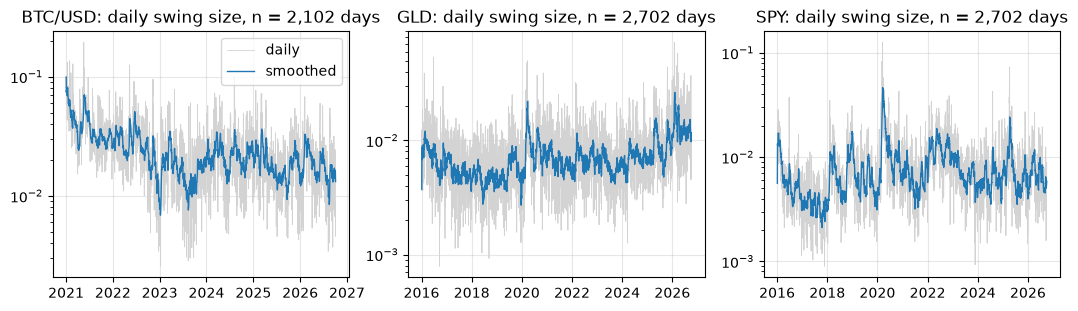

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
for ax, s in zip(axes, symbols):
    ax.plot(observations[s].index, observations[s]["rv"], color="lightgrey", linewidth=0.6, label="daily")
    ax.plot(observations[s].index, np.exp(observations[s]["log_rv"]), color="tab:blue", linewidth=1, label="smoothed")
    ax.set(title=f"{s}: daily swing size, n = {len(observations[s]):,} days", yscale="log")
axes[0].legend();

Volatility comes in clusters: quiet stretches and rough stretches. That clustering is
what makes the idea of "states" reasonable.

## 2. The fitted states

For each market: what a typical day looks like in each state, how long a stay in the
state usually lasts, and what usually comes next.

In [4]:
rows = []
for s in symbols:
    for state in regime.transition_summary(models[s]):
        rows.append(
            {
                "market": s,
                "state": state.label,
                "typical daily swing": state.typical_daily_volatility,
                "typical stay (days)": state.typical_duration_days,
                "usually next": max(state.next_states, key=state.next_states.get),
            }
        )
pd.DataFrame(rows).set_index(["market", "state"])

typical daily swing  typical stay (days) usually next
market  state                                                           
BTC/USD calm                    0.0145              36.9941       normal
        normal                  0.0223              20.4821         calm
        turbulent               0.0358              33.4518       normal
GLD     calm                    0.0050              41.7290       normal
        normal                  0.0073              30.6219         calm
        turbulent               0.0120              39.8939       normal
SPY     calm                    0.0039              33.1030       normal
        normal                  0.0060              22.1464    turbulent
        turbulent               0.0110              41.0217       normal

### Why three states?

BIC is a score that rewards fit and penalises complexity; lower is better. It often
prefers four states. Three are used anyway so that calm, normal, and turbulent mean
the same thing for every market. The table shows what was given up.

In [5]:
pd.DataFrame({s: models[s].bic_by_states for s in symbols}).rename_axis("states").round(0)

,BTC/USD,GLD,SPY
states,,,
2,9743.0000,12511.0000,11693.0000
3,8575.0000,10479.0000,9955.0000
4,7687.0000,9482.0000,8706.0000


## 3. The states through time

Price, shaded by the state the model assigned **on that day, with no knowledge of
later days**.

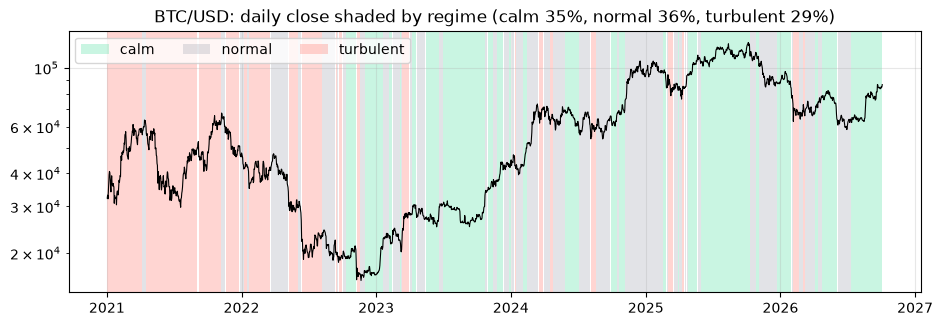

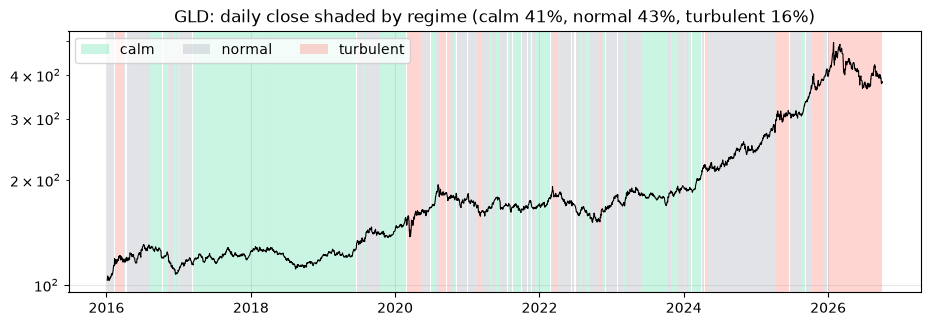

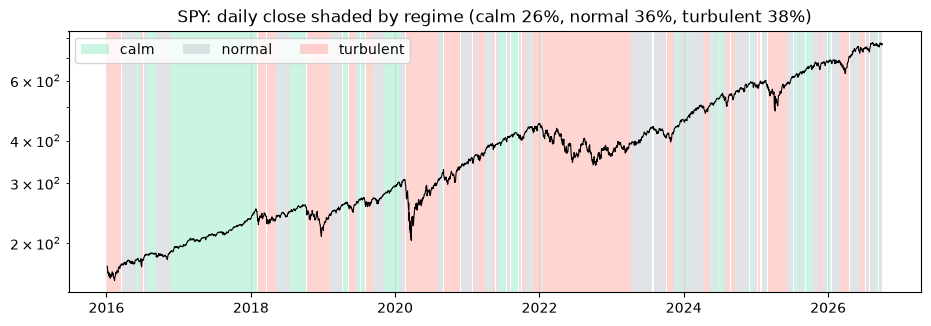

In [6]:
for s in symbols:
    probabilities = regime.filtered_probabilities(models[s], observations[s])
    labels = probabilities.idxmax(axis=1)
    price = closes[s].reindex(labels.index).ffill()
    fig, ax = plt.subplots()
    ax.plot(price.index, price.values, color="black", linewidth=0.8)
    ax.set_yscale("log")
    low, high = ax.get_ylim()
    for label, colour in COLOURS.items():
        ax.fill_between(price.index, low, high, where=(labels == label).to_numpy(), color=colour, alpha=0.28, label=label, linewidth=0)
    share = labels.value_counts(normalize=True)
    ax.set(title=f"{s}: daily close shaded by regime (" + ", ".join(f"{k} {share.get(k, 0):.0%}" for k in COLOURS) + ")", ylim=(low, high))
    ax.legend(loc="upper left", ncol=3)

### Filtered against smoothed: what hindsight changes

The last 250 days of turbulent-state probability for Bitcoin, both ways. Smoothed
(dashed) reacts earlier because it has seen what came next. The app only ever uses
the solid line.

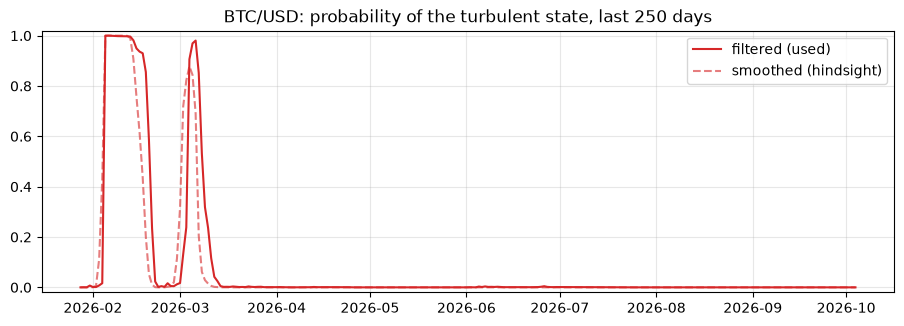

In [7]:
s = symbols[0]
filtered = regime.filtered_probabilities(models[s], observations[s])["turbulent"].iloc[-250:]
smoothed = regime.smoothed_probabilities(models[s], observations[s])["turbulent"].iloc[-250:]
fig, ax = plt.subplots()
ax.plot(filtered.index, filtered.values, color="tab:red", label="filtered (used)")
ax.plot(smoothed.index, smoothed.values, color="tab:red", linestyle="--", alpha=0.6, label="smoothed (hindsight)")
ax.set(title=f"{s}: probability of the turbulent state, last 250 days", ylim=(-0.02, 1.02))
ax.legend();

## 4. Does it work on days it had not seen?

Walk-forward test: the model is fitted on history up to a date, then labels the next
63 days it has never seen; then it is refitted and the window moves on. Every number
below comes from those unseen days.

The test of usefulness: after a day labelled turbulent, the **next** day's swings
should be larger than after a day labelled calm.

In [8]:
walk = {s: models[s + ":metrics"]["walk_forward"] for s in symbols}
pd.DataFrame(
    {
        s: {
            "unseen days tested": w["n_days"],
            "from": w["first_test_day"],
            "to": w["last_test_day"],
            **{f"next-day swing after {k}": v for k, v in w["next_day_volatility"].items()},
            "in the right order": w["volatility_is_ordered"],
            "average run of one state (days)": w["average_run_length"],
        }
        for s, w in walk.items()
    }
).T

,unseen days tested,from,to,next-day swing after calm,next-day swing after normal,next-day swing after turbulent,in the right order,average run of one state (days)
BTC/USD,1602,2022-05-17,2026-10-04,0.0196,0.0271,0.0363,True,34.0851
GLD,2202,2017-12-28,2026-10-02,0.0061,0.0075,0.0114,True,16.8092
SPY,2202,2017-12-28,2026-10-02,0.0054,0.0067,0.0124,True,21.8020


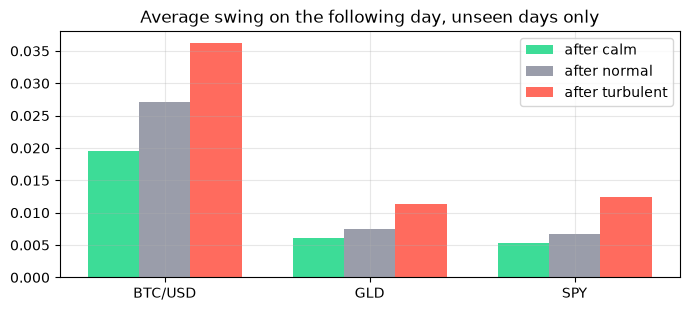

In [9]:
fig, ax = plt.subplots(figsize=(8, 3.2))
width = 0.25
for i, label in enumerate(COLOURS):
    ax.bar(np.arange(len(symbols)) + (i - 1) * width, [walk[s]["next_day_volatility"][label] for s in symbols], width, color=COLOURS[label], label=f"after {label}")
ax.set(xticks=np.arange(len(symbols)), xticklabels=symbols, title="Average swing on the following day, unseen days only")
ax.legend();

### Against a simple rule

The rival is a rule with no model: sort days into three groups by their average
volatility over the previous 30 days. Both are scored by how well they predicted each
unseen day's return and swing (average log density; higher is better).

In [10]:
pd.DataFrame(
    {
        s: {
            "hidden Markov model": w["model_log_density"],
            "30-day rule": w["baseline_log_density"],
            "model is better": w["model_log_density"] > w["baseline_log_density"],
        }
        for s, w in walk.items()
    }
).T

,hidden Markov model,30-day rule,model is better
BTC/USD,2.0168,1.9721,True
GLD,3.4400,3.0538,True
SPY,3.1835,2.5584,True


## What to take from this

- The states are real in the sense that matters: on unseen days, rougher states were
  followed by larger swings, for all three markets.
- A regime is detected **after** it begins. The model describes the present; it does
  not call turning points.
- Crypto history starts in 2021, so its states are learned from few market cycles.